In [1]:
import os
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

processed_path = "../data/processed/"
os.makedirs(processed_path, exist_ok=True)

OUTPUT_PATH = "model_assets/model_4/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

RANDOM_SEED = 42
SAMPLE_SEED = 6420

np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

PROCESSED = pathlib.Path("../data/processed/modeling_df.parquet")
REFERENCE = pathlib.Path("../data/reference/modeling_df.parquet")

if PROCESSED.exists():
    modeling_parquet = PROCESSED
else:
    print(
        "[warning] data/processed/modeling_df.parquet not found — "
        "falling back to committed frozen reference at data/reference/. "
        "Run bin/build.sh for the fresh pipeline output."
    )
    modeling_parquet = REFERENCE

[warning] data/processed/modeling_df.parquet not found — falling back to committed frozen reference at data/reference/. Run bin/build.sh for the fresh pipeline output.


# Model 4 - Sex + measured anthropometrics

Builds on Model 3. Adds three z-scored subject-level predictors: leg length, inter-ASIS distance, mass.

### Structure change from Model 3
- Subject intercepts pool toward a linear predictor of sex + anthropometrics:
  `alpha_subject ~ Normal(alpha_sex[sex] + X @ beta, sigma_subject)`
- Three new coefficients: `beta_leg`, `beta_iad`, `beta_mass`
- All predictors standardized: z-scored across the 47 subjects (not 2 SD, since these are continuous)

### Key question
Does measured body geometry explain any of the cadence error variance that sex couldn't?
- If yes: Invisible Women thesis holds at the body-geometry level even when it doesn't hold at the sex level.
- If no: mean-level demographic bias is not the story. The algorithm's failures are individual-level idiosyncrasy.

### Collinearity caveat
Leg length, IAD, and mass are correlated with each other and with sex. Individual coefficients might be hard to interpret. Will check the correlation matrix before fitting.

## Load data, build modeling frame

In [2]:
df_all = pd.read_parquet(modeling_parquet)
df = df_all[df_all["modeling_include"]].copy()

print('Cadence Error Summary')
print(df["cadence_error"].describe().round(2))

assert len(df) == 2781
assert df["subject_id"].nunique() == 47
assert df["cadence_error"].isnull().sum() == 0

Cadence Error Summary
count    2781.00
mean       -5.52
std        11.22
min       -74.28
25%        -7.09
50%        -2.96
75%        -0.40
max        33.57
Name: cadence_error, dtype: float64


## Check anthropometric columns and correlations

Confirm the expected columns exist and look at the correlation structure before z-scoring. High correlations between predictors will make individual coefficients hard to interpret.

In [3]:
# Extract one row per subject for anthropometric inspection
subjects_anthro = (
    df[['subject_id', 'sex', 'leg_length_mm', 'iad_mm', 'mass_kg']]
    .drop_duplicates()
    .set_index('subject_id')
    .sort_index()
)

print(f"\nn subjects: {len(subjects_anthro)}")
print("\nSummary:")
print(subjects_anthro[['leg_length_mm', 'iad_mm', 'mass_kg']].describe().round(1))
print("\nBy sex:")
print(subjects_anthro.groupby('sex')[['leg_length_mm', 'iad_mm', 'mass_kg']].mean().round(1))
print("\nCorrelations:")
# include sex as binary for the corr matrix
subjects_anthro['sex_M'] = (subjects_anthro['sex'] == 'M').astype(int)
print(subjects_anthro[['sex_M', 'leg_length_mm', 'iad_mm', 'mass_kg']].corr().round(2))

# check for NaN
print("\nNaN counts:")
print(subjects_anthro[['leg_length_mm', 'iad_mm', 'mass_kg']].isnull().sum())


n subjects: 47

Summary:
       leg_length_mm  iad_mm  mass_kg
count           47.0    47.0     47.0
mean           821.3   237.2     76.4
std             43.4    17.1     14.3
min            739.0   193.0     54.1
25%            788.5   228.0     66.9
50%            817.0   236.0     75.5
75%            863.8   249.5     83.0
max            893.5   285.0    136.1

By sex:
     leg_length_mm  iad_mm  mass_kg
sex                                
F            803.7   239.5     69.6
M            831.2   235.9     80.3

Correlations:
               sex_M  leg_length_mm  iad_mm  mass_kg
sex_M           1.00           0.31   -0.10     0.36
leg_length_mm   0.31           1.00    0.00     0.29
iad_mm         -0.10           0.00    1.00     0.42
mass_kg         0.36           0.29    0.42     1.00

NaN counts:
leg_length_mm    0
iad_mm           0
mass_kg          0
dtype: int64


### Anthropometric correlations

No collinearity dealbreakers:
- sex_M correlated modestly with leg (0.31) and mass (0.36), not with IAD (-0.10).
- IAD is slightly NEGATIVE with sex_M - women have slightly wider pelves in this cohort, opposite direction from leg/mass.
- Leg and IAD are independent (0.00). Leg-mass and IAD-mass are moderately correlated (0.29, 0.42).
- Individual coefficients should be interpretable.

Cohort note: sex differences in body geometry are smaller than expected in this sample. M leg length 831 vs F 804 (27mm). That's less than 1 SD of the overall distribution. This cohort is more overlapping than a random population sample would be. Limitation for the writeup.

High-leverage point: one subject at 136kg, z=+4.2. Their subject intercept posterior will be sensitive to how much beta_mass explains their deviation.

## Build coordinates, indices, speed dummies, and standardized anthropometrics

Same coords and indices as Models 1-3. Added: z-scored anthropometrics per subject. z-scoring by 1 SD (not 2 SD) since these are continuous and not mixed with binary indicators.

In [4]:
subject_ids = sorted(df['subject_id'].unique())
coords = {
    'subject': subject_ids,
    'sex': ['F', 'M'],
    'speed_nonref': ['slow','fast'],
    'obs': np.arange(len(df))
}

subject_idx = pd.Categorical(df['subject_id'], categories=coords['subject']).codes

subjects_df = (
    df[['subject_id', 'sex', 'leg_length_mm', 'iad_mm', 'mass_kg']]
    .drop_duplicates()
    .set_index('subject_id')
    .loc[coords['subject']]
    .reset_index()
)
sex_of_subject_idx = pd.Categorical(subjects_df['sex'], categories=coords['sex']).codes

# z-score anthropometrics (1 SD, not 2 SD)
leg_z = ((subjects_df['leg_length_mm'] - subjects_df['leg_length_mm'].mean()) / subjects_df['leg_length_mm'].std()).to_numpy()
iad_z = ((subjects_df['iad_mm'] - subjects_df['iad_mm'].mean()) / subjects_df['iad_mm'].std()).to_numpy()
mass_z = ((subjects_df['mass_kg'] - subjects_df['mass_kg'].mean()) / subjects_df['mass_kg'].std()).to_numpy()

speed_dummies = pd.get_dummies(df['speed'])
slow_dummy = speed_dummies['slow'].to_numpy().astype(float)
fast_dummy = speed_dummies['fast'].to_numpy().astype(float)

cadence_error = df['cadence_error'].to_numpy()

assert len(subject_idx) == len(df)
assert subject_idx.min() == 0 and subject_idx.max() == 46
assert len(sex_of_subject_idx) == 47
assert sex_of_subject_idx.sum() == 30
assert len(leg_z) == 47 and len(iad_z) == 47 and len(mass_z) == 47
assert np.isclose(leg_z.mean(), 0) and np.isclose(leg_z.std(ddof=1), 1)

print(f"subjects: {len(coords['subject'])}")
print(f"F/M: {(sex_of_subject_idx == 0).sum()}/{(sex_of_subject_idx == 1).sum()}")
print(f"leg_z:  mean {leg_z.mean():.2f}, sd {leg_z.std(ddof=1):.2f}, range [{leg_z.min():.2f}, {leg_z.max():.2f}]")
print(f"iad_z:  mean {iad_z.mean():.2f}, sd {iad_z.std(ddof=1):.2f}, range [{iad_z.min():.2f}, {iad_z.max():.2f}]")
print(f"mass_z: mean {mass_z.mean():.2f}, sd {mass_z.std(ddof=1):.2f}, range [{mass_z.min():.2f}, {mass_z.max():.2f}]")

subjects: 47
F/M: 17/30
leg_z:  mean -0.00, sd 1.00, range [-1.90, 1.67]
iad_z:  mean -0.00, sd 1.00, range [-2.59, 2.80]
mass_z: mean 0.00, sd 1.00, range [-1.55, 4.17]


## Model 4: Sex + anthropometrics

Same structure as Model 3 with three new subject-level continuous predictors added to the mean of `alpha_subject`. Sex structure stays. Partial pooling strength on subjects (`sigma_subject`) is now conditional on sex + anthropometrics, so it represents residual between-subject variation after all subject-level predictors are accounted for.

### Structure
- mu_pop ~ Normal(0, 10)
- sigma_sex ~ HalfNormal(5)
- alpha_sex_offset ~ Normal(0, 1) dims=sex
- alpha_sex = mu_pop + sigma_sex * alpha_sex_offset
- beta_leg, beta_iad, beta_mass ~ Normal(0, 5)
- subject_mean = alpha_sex[sex] + beta_leg * leg_z + beta_iad * iad_z + beta_mass * mass_z
- alpha_subject ~ Normal(subject_mean, sigma_subject) dims=subject
- rest is identical to Model 3

### Priors on anthropometric coefficients
- `Normal(0, 5)`. Same as beta_slow/fast. Weakly informative.
- Units: spm per SD of predictor. Prior says "the effect of a 1-SD change in leg length (or IAD, or mass) on cadence bias is centered at 0 with 95% mass in +/- 10 spm." Reasonable.

### Non-centering strategy
Same as Model 3: alpha_sex non-centered, alpha_subject centered. target_accept=0.995.

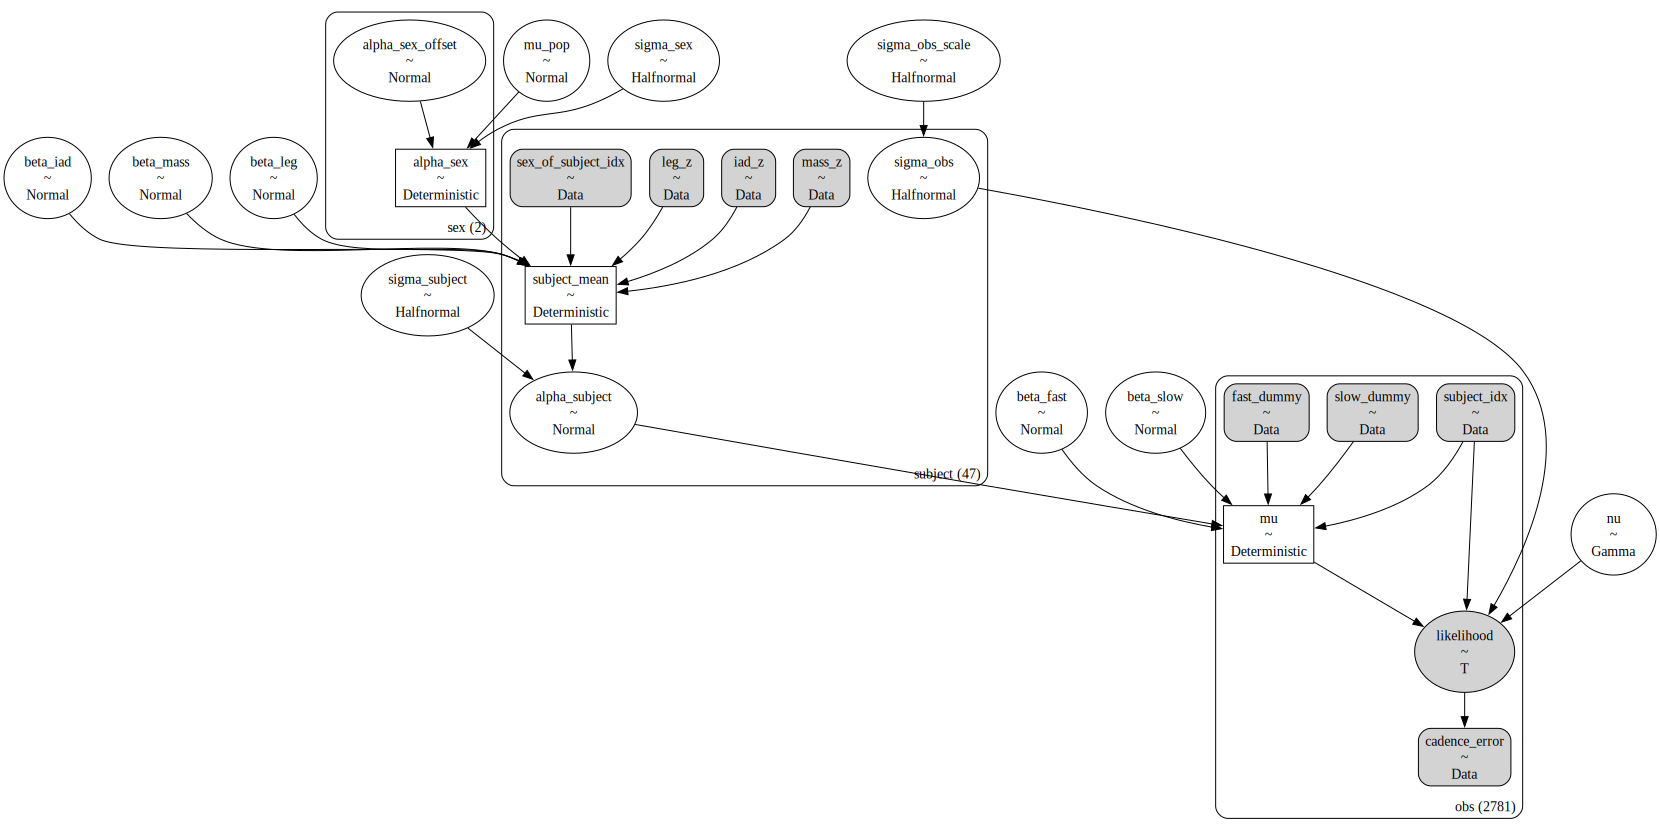

In [5]:
with pm.Model(coords=coords) as model_4:

    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    sidx = pm.Data('subject_idx', subject_idx, dims='obs')
    ssex = pm.Data('sex_of_subject_idx', sex_of_subject_idx, dims='subject')
    leg = pm.Data('leg_z', leg_z, dims='subject')
    iad = pm.Data('iad_z', iad_z, dims='subject')
    mass = pm.Data('mass_z', mass_z, dims='subject')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    mu_pop = pm.Normal('mu_pop', mu=0, sigma=10)
    sigma_sex = pm.HalfNormal('sigma_sex', sigma=5)

    alpha_sex_offset = pm.Normal('alpha_sex_offset', mu=0, sigma=1, dims='sex')
    alpha_sex = pm.Deterministic('alpha_sex', mu_pop + sigma_sex * alpha_sex_offset, dims='sex')

    beta_leg = pm.Normal('beta_leg', mu=0, sigma=5)
    beta_iad = pm.Normal('beta_iad', mu=0, sigma=5)
    beta_mass = pm.Normal('beta_mass', mu=0, sigma=5)

    subject_mean = pm.Deterministic(
        'subject_mean',
        alpha_sex[ssex] + beta_leg * leg + beta_iad * iad + beta_mass * mass,
        dims='subject'
    )

    sigma_subject = pm.HalfNormal('sigma_subject', sigma=5)
    alpha_subject = pm.Normal('alpha_subject', mu=subject_mean, sigma=sigma_subject, dims='subject')

    sigma_obs_scale = pm.HalfNormal('sigma_obs_scale', sigma=10)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=sigma_obs_scale, dims='subject')

    nu = pm.Gamma('nu', alpha=2, beta=0.1)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)

    mu = pm.Deterministic(
        'mu',
        alpha_subject[sidx] + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    pm.StudentT('likelihood', nu=nu, mu=mu, sigma=sigma_obs[sidx], observed=y, dims='obs')

_dag = pm.model_to_graphviz(model_4)
_dag.render(f"{OUTPUT_PATH}model_4_dag", format="png", cleanup=True)
_dag

In [6]:
with model_4:
    idata_model_4 = pm.sample(
        draws=2000, tune=2000, chains=4,
        target_accept=0.995, random_seed=SAMPLE_SEED,
        idata_kwargs={"log_likelihood": True}
    )
    pm.sample_posterior_predictive(
        idata_model_4, extend_inferencedata=True, random_seed=SAMPLE_SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop, sigma_sex, alpha_sex_offset, beta_leg, beta_iad, beta_mass, sigma_subject, alpha_subject, sigma_obs_scale, sigma_obs, nu, beta_slow, beta_fast]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 73 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [likelihood]


Output()

In [7]:
az.summary(
    idata_model_4,
    var_names=['mu_pop', 'sigma_sex', 'alpha_sex', 'beta_leg', 'beta_iad', 'beta_mass', 'sigma_subject', 'sigma_obs_scale', 'beta_slow', 'beta_fast', 'nu'],
    hdi_prob=0.95
).round(3)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_pop,-3.252,2.137,-8.123,1.260,0.036,0.058,4771.0,3969.0,1.0
sigma_sex,2.260,2.166,0.000,6.676,0.033,0.032,3696.0,4568.0,1.0
alpha_sex[F],-3.680,0.779,-5.303,-2.236,0.010,0.007,6601.0,7248.0,1.0
alpha_sex[M],-3.033,0.574,-4.170,-1.926,0.007,0.006,7685.0,6844.0,1.0
beta_leg,-0.508,0.507,-1.521,0.470,0.005,0.006,12600.0,5594.0,1.0
beta_iad,0.026,0.530,-1.036,1.049,0.005,0.006,13201.0,6146.0,1.0
beta_mass,-0.149,0.578,-1.255,0.996,0.005,0.006,11516.0,6908.0,1.0
sigma_subject,3.059,0.421,2.307,3.915,0.005,0.005,8703.0,6426.0,1.0
sigma_obs_scale,5.263,0.594,4.182,6.481,0.005,0.007,12895.0,6608.0,1.0
beta_slow,1.040,0.173,0.698,1.374,0.002,0.002,6267.0,6549.0,1.0


### Model 4 headline: no detectable anthropometric effects

beta_leg  = -0.51, HDI [-1.52, +0.47]. Crosses zero.
beta_iad  = +0.03, HDI [-1.04, +1.05]. Symmetric around zero.
beta_mass = -0.15, HDI [-1.26, +1.00]. Crosses zero.

All three are centered near zero with HDIs of roughly +/- 1 spm. Taller subjects trend slightly toward more undercount (consistent with Sequeira 2000 hypothesis direction) but not detectably.

sigma_subject unchanged from Model 3 (3.06 vs 3.01). Anthropometrics absorbed zero subject variance.

Everything else identical to Model 2b/3:
- nu = 1.69
- sigma_obs_scale = 5.26
- beta_slow = 1.04, beta_fast = -1.22
- alpha_sex still overlapping

### Audit conclusion

Clean null at the mean level. 95% HDIs on sex means overlap. 95% HDIs on three body-geometry predictors all cross zero with +/- 1 spm widths.

Bayesian bound: given 17F/30M and the anthropometric spread in this cohort, any true demographic bias effect in cadence is credibly below +/- 1.5 spm.

Reframes Invisible Women for this specific outcome: the algorithm is roughly equally biased for everyone at mean level. What varies is the variance, not the mean. The left-shoulder asymmetry is trial-level idiosyncrasy, not demographic.

In [8]:
idata_model_2b = az.from_netcdf("../data/processed/idata_model_2b.nc")
idata_model_3 = az.from_netcdf("../data/processed/idata_model_3.nc")

comparison = az.compare(
    {
        "Model 2b": idata_model_2b,
        "Model 3 (+sex)": idata_model_3,
        "Model 4 (+sex +anthro)": idata_model_4,
    },
    ic="loo"
)
print(comparison)

                        rank     elpd_loo       p_loo  elpd_diff  weight  \
Model 3 (+sex)             0 -9306.435090  103.465765   0.000000     1.0   
Model 4 (+sex +anthro)     1 -9306.575332  103.953057   0.140242     0.0   
Model 2b                   2 -9306.649586  103.336079   0.214496     0.0   

                               se       dse  warning scale  
Model 3 (+sex)          75.874664  0.000000    False   log  
Model 4 (+sex +anthro)  75.853908  0.312828    False   log  
Model 2b                75.897090  0.193639    False   log  


### LOO three-way

All three models indistinguishable.
- elpd range across all three: 0.21 units
- dse > elpd_diff in all pairs
- Weight stacking artifact (weight 1.0 / 0.0 / 0.0, noise)

Sex adds nothing. Anthropometrics add nothing beyond sex. Model 2b's likelihood + per-subject sigma + subject intercepts captured all the structure there is to capture.

The null is confirmed quantitatively. Mean-level demographic bias is not a predictive signal.

/var/folders/n9/8tgrbsbx61n9yzm2f0wrchh00000gp/T/ipykernel_4577/2764150279.py:5: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(f"{OUTPUT_PATH}model_4_ppc_three_way.png", dpi=200, bbox_inches="tight")
/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


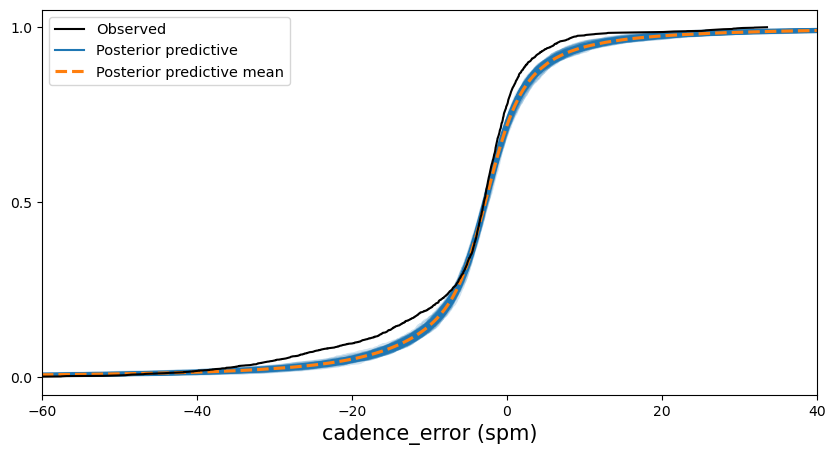

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
az.plot_ppc(idata_model_4, kind="cumulative", num_pp_samples=200, ax=ax)
ax.set_xlabel("cadence_error (spm)")
ax.set_xlim(-60, 40)
fig.savefig(f"{OUTPUT_PATH}model_4_ppc_three_way.png", dpi=200, bbox_inches="tight")
plt.show()

In [10]:
idata_model_4.to_netcdf("../data/processed/idata_model_4.nc")

az.summary(idata_model_4).to_csv(f"{OUTPUT_PATH}model_4_summary.csv")

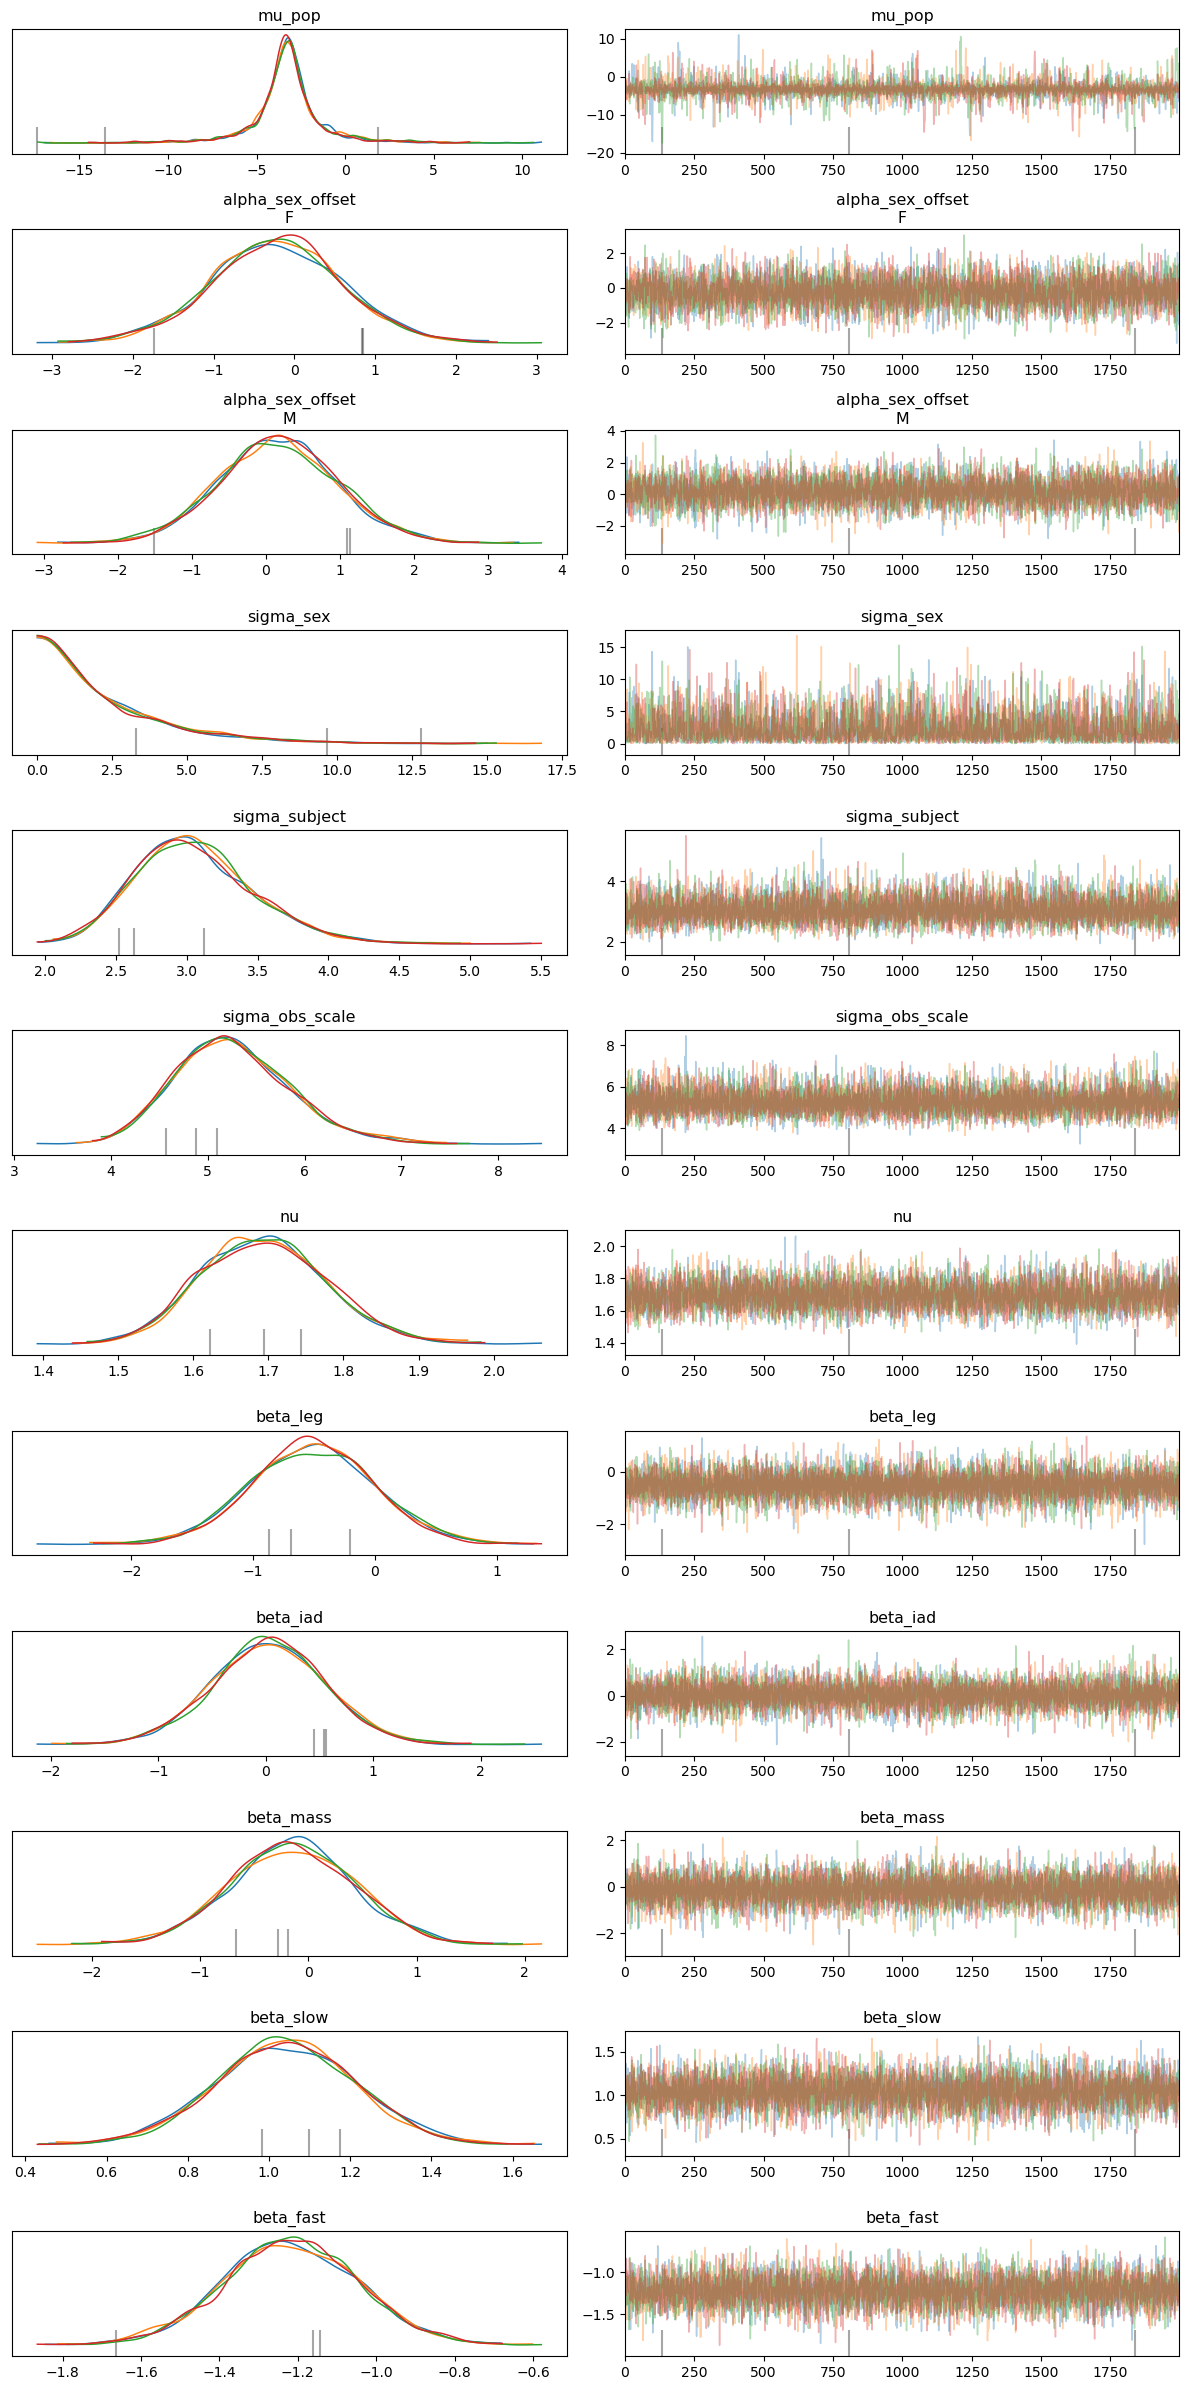

In [11]:
# Model 4 uses a non-centered parameterization for alpha_sex — we plot
# alpha_sex_offset (the raw sampled parameter) rather than alpha_sex (a
# Deterministic) since sampler-health diagnostics are meaningful on the
# sampled parameter, not on its transform.
az.plot_trace(
    idata_model_4,
    var_names=["mu_pop", "alpha_sex_offset", "sigma_sex", "sigma_subject",
               "sigma_obs_scale", "nu",
               "beta_leg", "beta_iad", "beta_mass",
               "beta_slow", "beta_fast"],
    compact=False,
)
plt.gcf().tight_layout()
plt.savefig(f"{OUTPUT_PATH}model_4_trace.png", dpi=200, bbox_inches="tight")
plt.show()

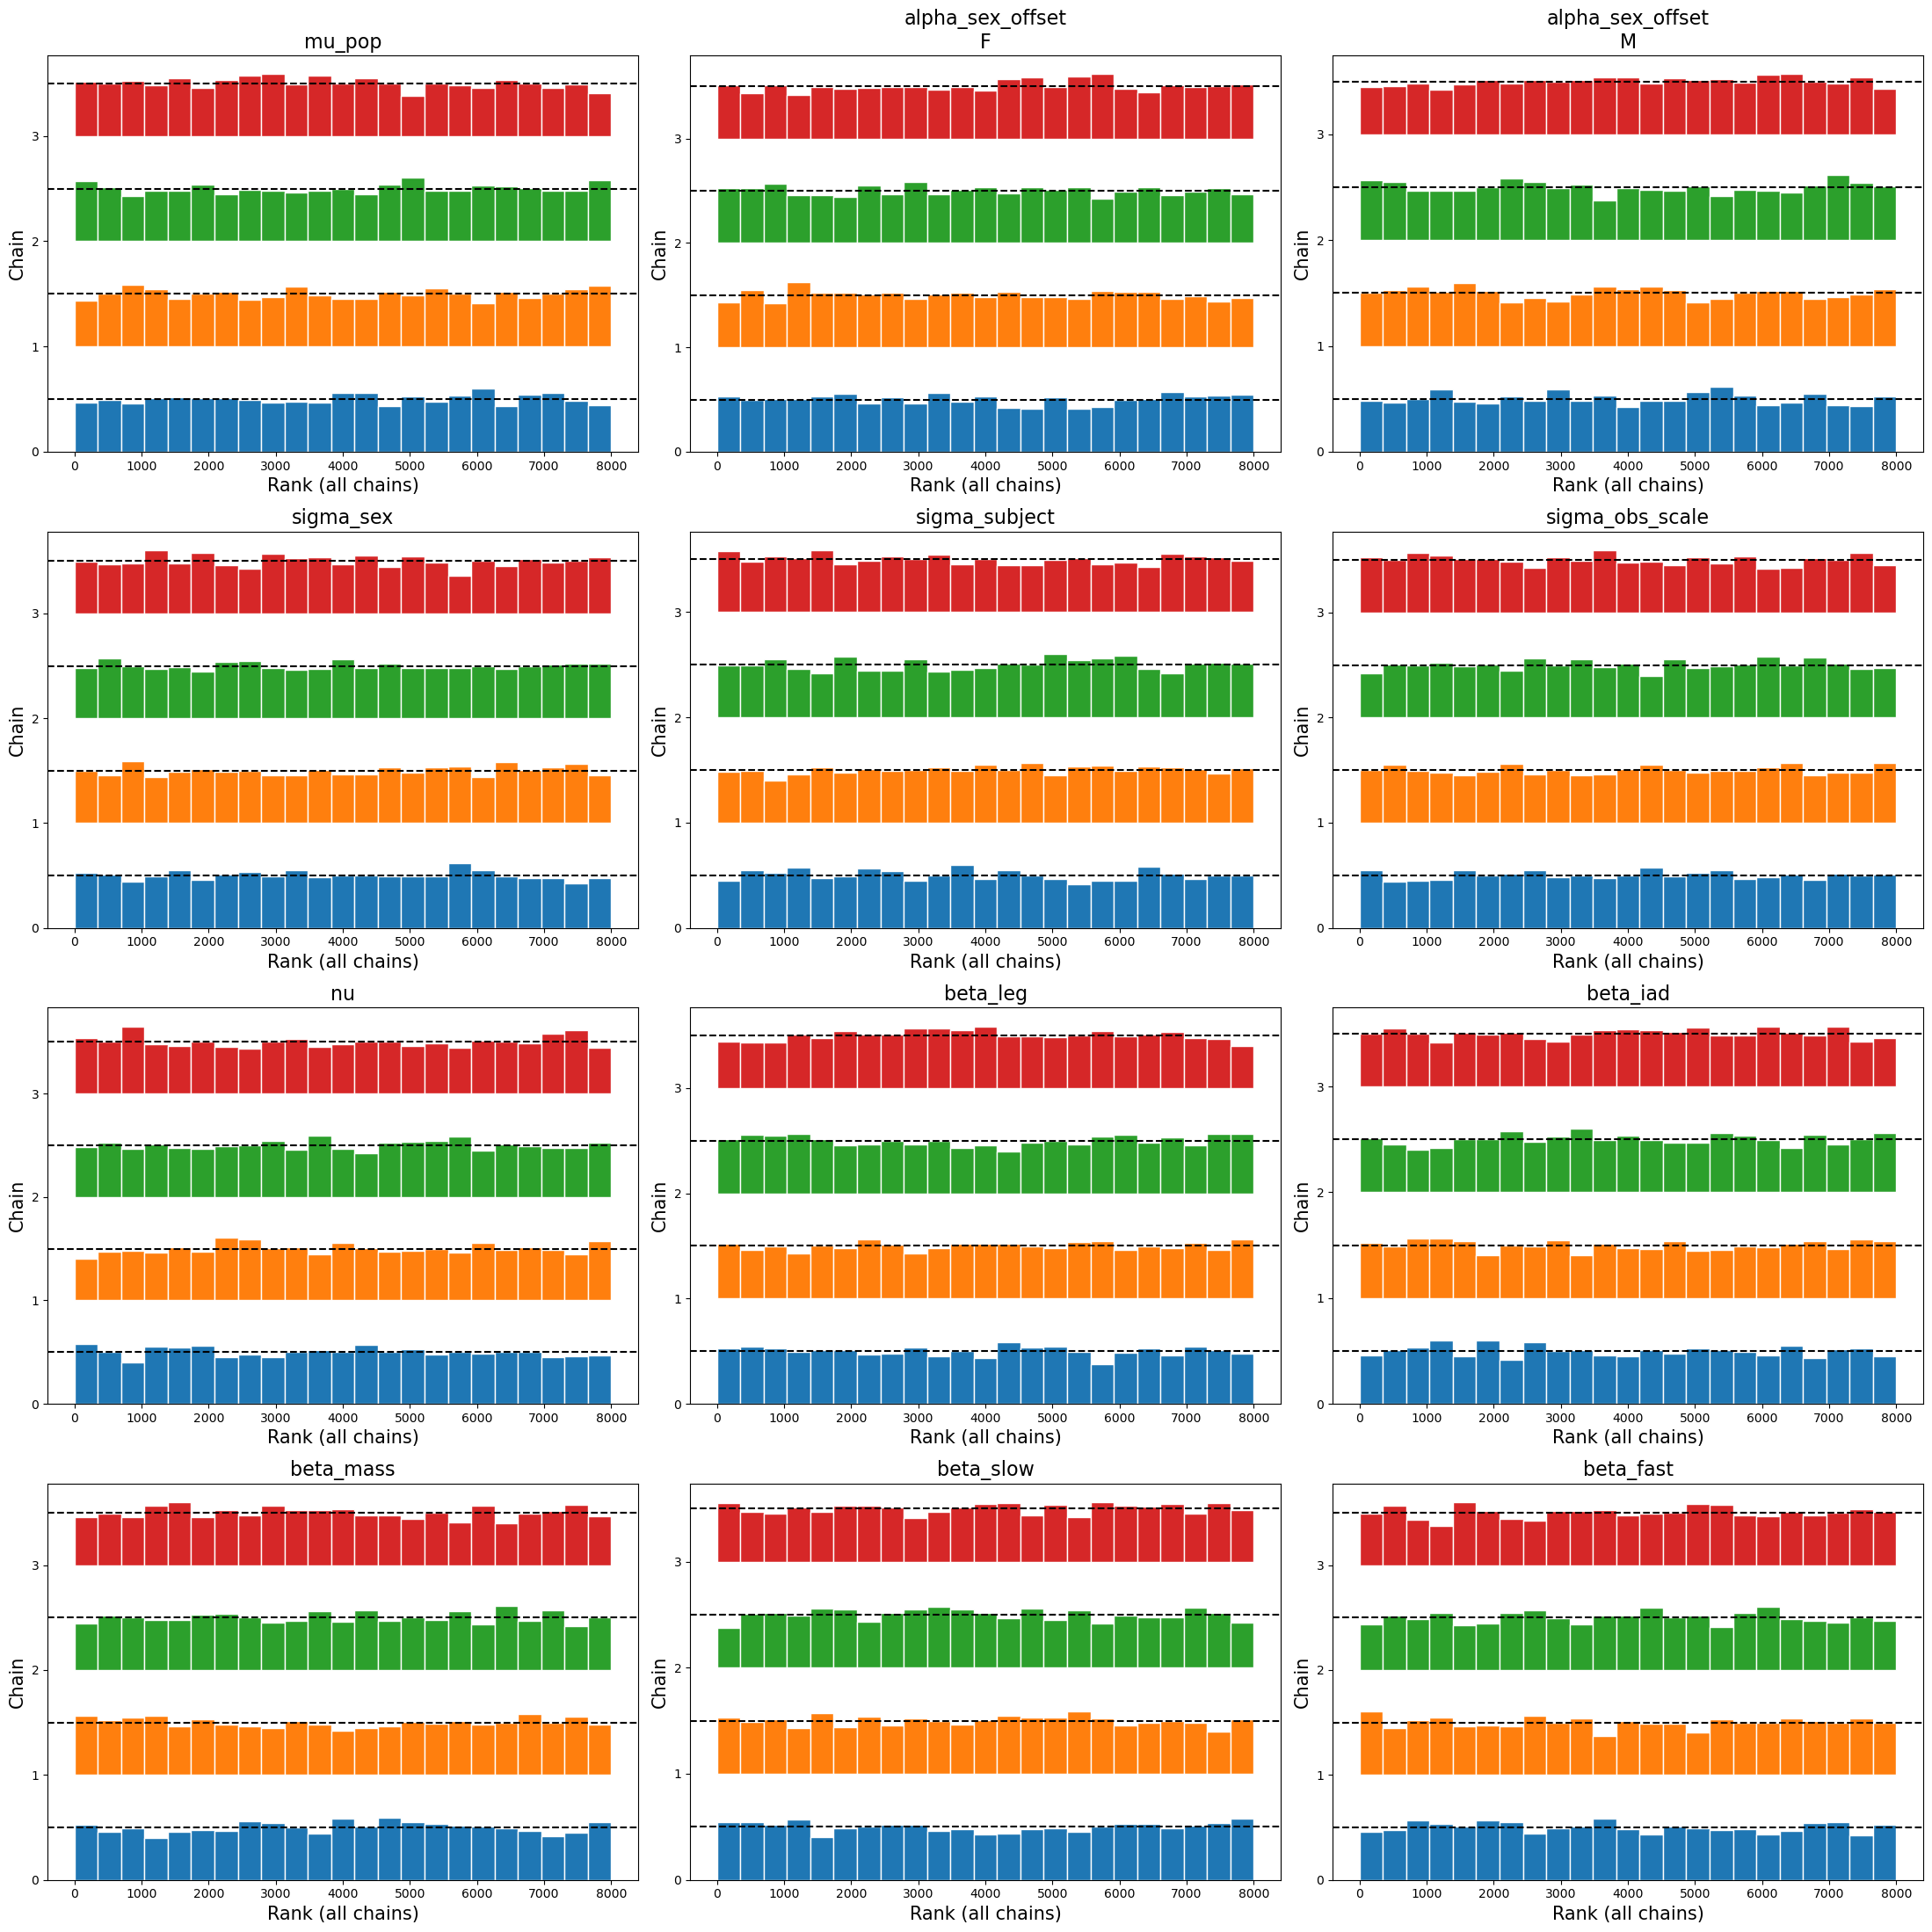

In [12]:
az.plot_rank(
    idata_model_4,
    var_names=["mu_pop", "alpha_sex_offset", "sigma_sex", "sigma_subject",
               "sigma_obs_scale", "nu",
               "beta_leg", "beta_iad", "beta_mass",
               "beta_slow", "beta_fast"],
)
plt.gcf().tight_layout()
plt.savefig(f"{OUTPUT_PATH}model_4_rank.png", dpi=200, bbox_inches="tight")
plt.show()

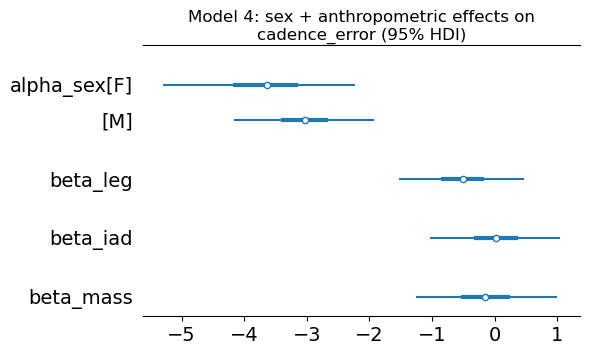

In [13]:
# Forest plot: Model 4 sex + anthropometric effects. This is the M4-only
# version of the cross-model forest (see model_comparison.ipynb for the
# M3 vs M4 overlay); saving it here lets M4 stand on its own for the writeup.
fig, ax = plt.subplots(figsize=(6, 3.5))
az.plot_forest(
    idata_model_4,
    var_names=["alpha_sex", "beta_leg", "beta_iad", "beta_mass"],
    combined=True, hdi_prob=0.95, ax=ax,
)
ax.set_title("Model 4: sex + anthropometric effects on cadence_error (95% HDI)")
fig.tight_layout()
fig.savefig(f"{OUTPUT_PATH}model_4_demographic_forest.png", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
# Per-model LOO (pointwise) for audit: Pareto-k distribution and headline.
# Saved as two CSVs so the report can cite `n_pareto_k > 0.7` without re-running.
loo_model_4 = az.loo(idata_model_4, pointwise=True)

pd.DataFrame({
    "elpd_i": loo_model_4.loo_i.values,
    "pareto_k": loo_model_4.pareto_k.values,
}).to_csv(f"{OUTPUT_PATH}model_4_loo_pointwise.csv", index=False)

pd.Series({
    "elpd_loo": float(loo_model_4.elpd_loo),
    "se":       float(loo_model_4.se),
    "p_loo":    float(loo_model_4.p_loo),
    "n_pareto_k_gt_07": int((loo_model_4.pareto_k.values > 0.7).sum()),
    "n_obs":    int(len(loo_model_4.pareto_k.values)),
}, name="value").rename_axis("metric").to_csv(f"{OUTPUT_PATH}model_4_loo_headline.csv")

In [15]:
anthropometric_correlations = (
    subjects_anthro[["sex_M", "leg_length_mm", "iad_mm", "mass_kg"]]
    .corr()
    .round(2)
)
print(anthropometric_correlations)
anthropometric_correlations.to_csv(
    f"{OUTPUT_PATH}model_4_anthropometric_correlations.csv"
)


               sex_M  leg_length_mm  iad_mm  mass_kg
sex_M           1.00           0.31   -0.10     0.36
leg_length_mm   0.31           1.00    0.00     0.29
iad_mm         -0.10           0.00    1.00     0.42
mass_kg         0.36           0.29    0.42     1.00
